# GLUP24 - EDA

#### Import de llibreries i warnings

In [1]:
# Exploració de dades
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## Estructura dataset

In [2]:
# Definim les columnes per tal de poder analitzar millor el dataset
cols = [
    'year', 'month', 'day', 'hour', 'minute', 'second', # A–F
    'glucose_level', # G
    'finger_stick', # H
    'basal', # I
    'bolus', # J
    'sleep', # K
    'work', # L
    'stressors', # M
    'hypo_event', # N
    'illness', # O
    'exercise', # P
    'basis_heart_rate', # Q
    'basis_gsr', # R
    'basis_skin_temperature', # S
    'basis_air_temperature',  # T
    'basis_step', # U
    'basis_sleep', # V
    'meal', # W
    'meal_type' # X
]

In [ ]:
df_559_train = pd.read_csv('../data/559/559_train.csv', sep=';', header=None, names=cols)
df_559_test = pd.read_csv('../data/559/559_test.csv', sep=';', header=None, names=cols)

# Display del train
display(df_559_train.head())
display(df_559_train.tail())

# Display del test
display(df_559_test.head())
display(df_559_test.tail())

df_559_train.info()

,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal,meal_type
0,2021,12,7,1,5,0,0,107,"0,65","1,6",0,0,0,0,0,0,0,0,0,0,0,0,25,0
1,2021,12,7,1,10,0,0,0,"0,65",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2021,12,7,1,15,0,101,0,"0,65",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2021,12,7,1,20,0,98,0,"0,65",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2021,12,7,1,25,0,104,0,"0,65",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal,meal_type
12078,2022,1,17,23,35,0,161,0,"0,83",0,3,0,0,0,0,0,58,"0,000213","92,3","89,6",0,94,0,0
12079,2022,1,17,23,40,0,164,0,"0,83",0,3,0,0,0,0,0,58,"0,000201","92,3","89,6",0,94,0,0
12080,2022,1,17,23,45,0,168,0,"0,83",0,3,0,0,0,0,0,58,"0,000198","92,3","89,6",0,94,0,0
12081,2022,1,17,23,50,0,172,0,"0,83",0,3,0,0,0,0,0,57,"0,000192","92,3","89,6",0,94,0,0
12082,2022,1,17,23,55,0,176,0,"0,83",0,3,0,0,0,0,0,58,"0,000188","92,3","89,6",0,94,0,0


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal,meal_type
0,2022,1,18,0,0,0,179,0,"0,83",0,3,0,0,0,0,0,57,"0,000183","92,3","89,6",0,94,0,0
1,2022,1,18,0,5,0,183,0,"0,83",0,3,0,0,0,0,0,57,"0,000182","92,3","89,6",0,94,0,0
2,2022,1,18,0,10,0,187,0,"0,83",0,3,0,0,0,0,0,57,"0,000177","92,3","89,6",0,94,0,0
3,2022,1,18,0,15,0,191,0,"0,83",0,3,0,0,0,0,0,56,"0,000169","92,3","89,6",0,94,0,0
4,2022,1,18,0,20,0,195,0,"0,83",0,3,0,0,0,0,0,56,"0,000166","92,3","89,6",0,94,0,0


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal,meal_type
2871,2022,1,27,23,15,0,185,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2872,2022,1,27,23,20,0,183,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2873,2022,1,27,23,25,0,182,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2874,2022,1,27,23,30,0,180,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2875,2022,1,27,23,35,0,177,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12083 entries, 0 to 12082
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   year                    12083 non-null  int64 
 1   month                   12083 non-null  int64 
 2   day                     12083 non-null  int64 
 3   hour                    12083 non-null  int64 
 4   minute                  12083 non-null  int64 
 5   second                  12083 non-null  int64 
 6   glucose_level           12083 non-null  int64 
 7   finger_stick            12083 non-null  int64 
 8   basal                   12083 non-null  object
 9   bolus                   12083 non-null  object
 10  sleep                   12083 non-null  int64 
 11  work                    12083 non-null  int64 
 12  stressors               12083 non-null  int64 
 13  hypo_event              12083 non-null  int64 
 14  illness                 12083 non-null  int64 
 15  ex

In [4]:
# Percentatge de valors nuls
print('Percentatge de valors nuls:', '\n')
print(df_559_train.isnull().mean()*100)

Percentatge de valors nuls: 

year                      0.0
month                     0.0
day                       0.0
hour                      0.0
minute                    0.0
second                    0.0
glucose_level             0.0
finger_stick              0.0
basal                     0.0
bolus                     0.0
sleep                     0.0
work                      0.0
stressors                 0.0
hypo_event                0.0
illness                   0.0
exercise                  0.0
basis_heart_rate          0.0
basis_gsr                 0.0
basis_skin_temperature    0.0
basis_air_temperature     0.0
basis_step                0.0
basis_sleep               0.0
meal                      0.0
meal_type                 0.0
dtype: float64


In [5]:
print('Estructura: ', df_559_train.shape)

num_col=df_559_train.select_dtypes(include=[np.number]).columns
cat_col = df_559_train.select_dtypes(exclude=[np.number]).columns

print(f'Columnes numèriques: {num_col.shape[0]} \n{num_col.tolist()} \n\nColumnes categòriques: {cat_col.shape[0]} \n{cat_col.tolist()}')


Estructura:  (12083, 24)
Columnes numèriques: 19 
['year', 'month', 'day', 'hour', 'minute', 'second', 'glucose_level', 'finger_stick', 'sleep', 'work', 'stressors', 'hypo_event', 'illness', 'exercise', 'basis_heart_rate', 'basis_step', 'basis_sleep', 'meal', 'meal_type'] 

Columnes categòriques: 5 
['basal', 'bolus', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature']


In [6]:
for col in ['basal','bolus','basis_gsr','basis_skin_temperature','basis_air_temperature', 'meal_type']: # Incluim meal_type ja que hauria de ser catagorica
    print('--'*50,'\n', df_559_train[col].value_counts())

---------------------------------------------------------------------------------------------------- 
 basal
1,25    4230
0,9     1778
1,15    1583
0,65    1306
0,73    1045
0,83     835
0,88     690
0        616
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------- 
 bolus
0      11932
3,3       12
5,5       10
2,7        9
4,4        8
5          7
3,8        7
6,6        6
7,2        4
2          4
1,6        4
2,2        4
6,5        3
2,5        3
2,4        3
0,8        3
2,3        3
4,1        3
3          3
3,9        3
1,1        2
0,1        2
6,1        2
4,2        2
6,3        2
0,6        2
0,3        2
4          2
1,7        2
2,9        2
0,5        2
4,6        2
0,7        1
9,3        1
4,5        1
1,3        1
5,2        1
9,2        1
0,2        1
7          1
1,8        1
3,4        1
2,6        1
1,2        1
5,4        1
3,2        1
3,6        1
1,4        1
6          1
4,9        1
2,

In [ ]:
# Convertim numeriques en categoriques
for col in ['basal','bolus','basis_gsr','basis_skin_temperature','basis_air_temperature']:
    df_559_train[col] = df_559_train[col].astype(str) # Asegurem que sigui string
    df_559_train[col] = df_559_train[col].str.replace(',', '.', regex=False) # Subsituim coma per punt
    
    df_559_train[col] = df_559_train[col].str.strip() # Tallem possibles espais en balnc
    df_559_train[col] = pd.to_numeric(df_559_train[col], errors='coerce')

# Reconvertim meal type a categorica
df_559_train['meal_type'] = df_559_train['meal_type'].astype('category')

# Categories de meal
cat_meal = {
    1: 'Desayuno',
    2: 'Almuerzo',
    3: 'Cena',
    4: 'Snack',
    5: 'Corrección hipo'
}

df_559_train['meal_type'] = (df_559_train['meal_type'].cat.rename_categories(cat_meal))


# Sleep i work no cal reconvertirles a categoriques ja que segueixen una logica 1 dolen 3 bo i del 1-10 esforç

In [8]:
for col in ['basal','bolus','basis_gsr','basis_skin_temperature','basis_air_temperature', 'meal_type']:
    print('--'*50,'\n', df_559_train[col].value_counts())

---------------------------------------------------------------------------------------------------- 
 basal
1.25    4230
0.90    1778
1.15    1583
0.65    1306
0.73    1045
0.83     835
0.88     690
0.00     616
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------- 
 bolus
0.0    11932
3.3       12
5.5       10
2.7        9
4.4        8
5.0        7
3.8        7
6.6        6
7.2        4
2.0        4
1.6        4
2.2        4
6.5        3
2.5        3
2.4        3
0.8        3
2.3        3
4.1        3
3.0        3
3.9        3
1.1        2
0.1        2
6.1        2
4.2        2
6.3        2
0.6        2
0.3        2
4.0        2
1.7        2
2.9        2
0.5        2
4.6        2
0.7        1
9.3        1
4.5        1
1.3        1
5.2        1
9.2        1
0.2        1
7.0        1
1.8        1
3.4        1
2.6        1
1.2        1
5.4        1
3.2        1
3.6        1
1.4        1
6.0        1
4.9        1
2.

In [9]:
# Remplacem el 0 per nan del meal_type
df_559_train.loc[df_559_train['meal_type'] == 0, 'meal_type'] = np.nan
df_559_train['meal_type'] = df_559_train['meal_type'].astype('category')

In [10]:
print('Estructura: ', df_559_train.shape)

num_col=df_559_train.select_dtypes(include=[np.number]).columns
cat_col = df_559_train.select_dtypes(exclude=[np.number]).columns

print(f'Columnes numèriques: {num_col.shape[0]} \n{num_col.tolist()} \n\nColumnes categòriques: {cat_col.shape[0]} \n{cat_col.tolist()}')


Estructura:  (12083, 24)
Columnes numèriques: 23 
['year', 'month', 'day', 'hour', 'minute', 'second', 'glucose_level', 'finger_stick', 'basal', 'bolus', 'sleep', 'work', 'stressors', 'hypo_event', 'illness', 'exercise', 'basis_heart_rate', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature', 'basis_step', 'basis_sleep', 'meal'] 

Columnes categòriques: 1 
['meal_type']


## Anàlisi Univariada

### Anàlisi de Variables numèriques

In [11]:
df_559_train[num_col].describe()


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal
count,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.0,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000
mean,2021.405197,7.542829,14.960937,11.512290,27.502276,0.0,148.937350,2.700902,0.961694,0.046470,0.747414,0.674501,0.000083,0.000579,0.000331,0.082513,69.931308,0.329978,83.069017,79.886997,2.960689,31.560788,0.482579
std,0.490951,5.400456,8.047767,6.916037,17.259878,0.0,84.232591,25.763226,0.313345,0.467974,1.110703,1.607918,0.009097,0.024063,0.018192,0.635845,22.069571,1.756626,19.772954,19.213183,13.062265,44.001539,4.453340
min,2021.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021.000000,1.000000,9.000000,6.000000,15.000000,0.0,94.000000,0.000000,0.830000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.000000,0.000075,84.740000,80.780000,0.000000,0.000000,0.000000
50%,2021.000000,12.000000,14.000000,12.000000,30.000000,0.0,145.000000,0.000000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,68.000000,0.000092,87.080000,83.300000,0.000000,0.000000,0.000000
75%,2022.000000,12.000000,21.000000,18.000000,42.500000,0.0,204.000000,0.000000,1.250000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,81.000000,0.000354,90.140000,87.080000,0.000000,90.000000,0.000000
max,2022.000000,12.000000,31.000000,23.000000,55.000000,0.0,400.000000,586.000000,1.250000,9.300000,3.000000,6.000000,1.000000,1.000000,1.000000,6.000000,189.000000,21.600000,95.900000,96.980000,127.000000,97.000000,75.000000


* **`second`**: valor constant (0) en totes les files → no aporta informació; es pot eliminar.
* **`month`**: 25 % de registres al mes 1 però el 50 % ja al 12; revisar la càrrega de mesos.
* **`basal`**: mitjana ≃0.96 U, desviació ≃0.31 U i rang \[0, 1.25] → coherent amb taxes basals reals.
* **`bolus`**: 75 % de zeros però un màxim de 9.3 U → pocs cops amb bolo, però de mida variable.
* **`sleep`/`work`**: majoritàriament zeros (indicadors d’inactivitat) i valors positius només durant l’activitat; sembla correcte.
* **Sensors (`basis_*`)**: ara tots tenen zeros que representen “no disponible”;
* **`meal`**: mitjana ≃0.48 i màxim 75 — cal confirmar si mesura grams de carbohidrats o un altre indicador.


In [12]:
# Eliminem la columna seconds
df_559_train = df_559_train.drop(columns='second')
num_col=df_559_train.select_dtypes(include=[np.number]).columns

In [13]:
# Corregim valor no coherents
invalid_zero = [
    'glucose_level',          
    'finger_stick',           
    'basis_heart_rate',       
    'basis_gsr',              
    'basis_skin_temperature', 
    'basis_air_temperature',  
    'meal'                    
]

for col in invalid_zero:
    if col in df_559_train.columns:
        df_559_train[col] = df_559_train[col].replace(0, np.nan)

# Percentatge de valors nuls
print('Percentatge de valors nuls:', '\n')
print(df_559_train.isnull().mean()*100)

Percentatge de valors nuls: 

year                       0.000000
month                      0.000000
day                        0.000000
hour                       0.000000
minute                     0.000000
glucose_level             10.651328
finger_stick              98.584789
basal                      0.000000
bolus                      0.000000
sleep                      0.000000
work                       0.000000
stressors                  0.000000
hypo_event                 0.000000
illness                    0.000000
exercise                   0.000000
basis_heart_rate           4.907722
basis_gsr                  5.619465
basis_skin_temperature     5.213937
basis_air_temperature      5.213937
basis_step                 0.000000
basis_sleep                0.000000
meal                      98.601341
meal_type                 98.783415
dtype: float64


In [14]:
df_559_train[num_col].describe()

,year,month,day,hour,minute,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal
count,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,10796.000000,171.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,11490.000000,11404.000000,11453.000000,11453.000000,12083.000000,12083.000000,169.000000
mean,2021.405197,7.542829,14.960937,11.512290,27.502276,166.692293,190.847953,0.961694,0.046470,0.747414,0.674501,0.000083,0.000579,0.000331,0.082513,73.540470,0.349626,87.638429,84.281375,2.960689,31.560788,34.502959
std,0.490951,5.400456,8.047767,6.916037,17.259878,70.577174,105.137838,0.313345,0.467974,1.110703,1.607918,0.009097,0.024063,0.018192,0.635845,15.708696,1.806269,3.462183,4.365483,13.062265,44.001539,15.667727
min,2021.000000,1.000000,1.000000,0.000000,0.000000,40.000000,46.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,46.000000,0.000068,72.320000,63.860000,0.000000,0.000000,8.000000
25%,2021.000000,1.000000,9.000000,6.000000,15.000000,108.000000,106.000000,0.830000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,62.000000,0.000076,85.100000,81.320000,0.000000,0.000000,20.000000
50%,2021.000000,12.000000,14.000000,12.000000,30.000000,157.000000,182.000000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000097,87.440000,83.660000,0.000000,0.000000,30.000000
75%,2022.000000,12.000000,21.000000,18.000000,42.500000,212.000000,247.000000,1.250000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,82.000000,0.000437,90.320000,87.440000,0.000000,90.000000,45.000000
max,2022.000000,12.000000,31.000000,23.000000,55.000000,400.000000,586.000000,1.250000,9.300000,3.000000,6.000000,1.000000,1.000000,1.000000,6.000000,189.000000,21.600000,95.900000,96.980000,127.000000,97.000000,75.000000


#### Visualització de la Distribució de dades

### Anàlisi de Variables Categòriques

In [15]:
print('Variables categoriques:\n\n', cat_col.tolist())
display(df_559_train[cat_col].head())

print(df_559_train[cat_col].value_counts())

Variables categoriques:

 ['meal_type']


,meal_type
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


meal_type      
Desayuno           41
Cena               38
Almuerzo           34
Snack              27
Corrección hipo     7
0                   0
Name: count, dtype: int64


In [16]:

df_559_train['meal_type'] = df_559_train['meal_type'].astype('category')

Text(0.5, 1.0, 'MEAL TYPE')

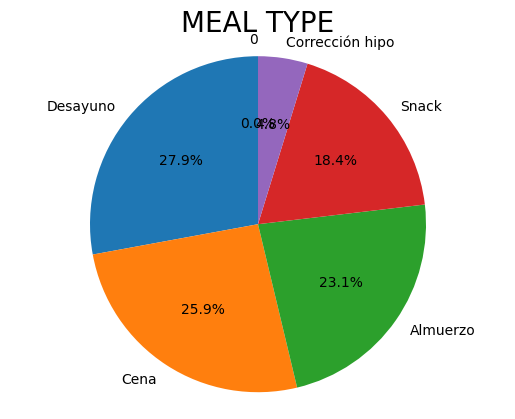

In [17]:
percent = df_559_train['meal_type'].value_counts()/df_559_train.shape[0]*100

plt.pie(percent, labels=percent.index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('MEAL TYPE', size=20)

## Anàlisi Bivariada

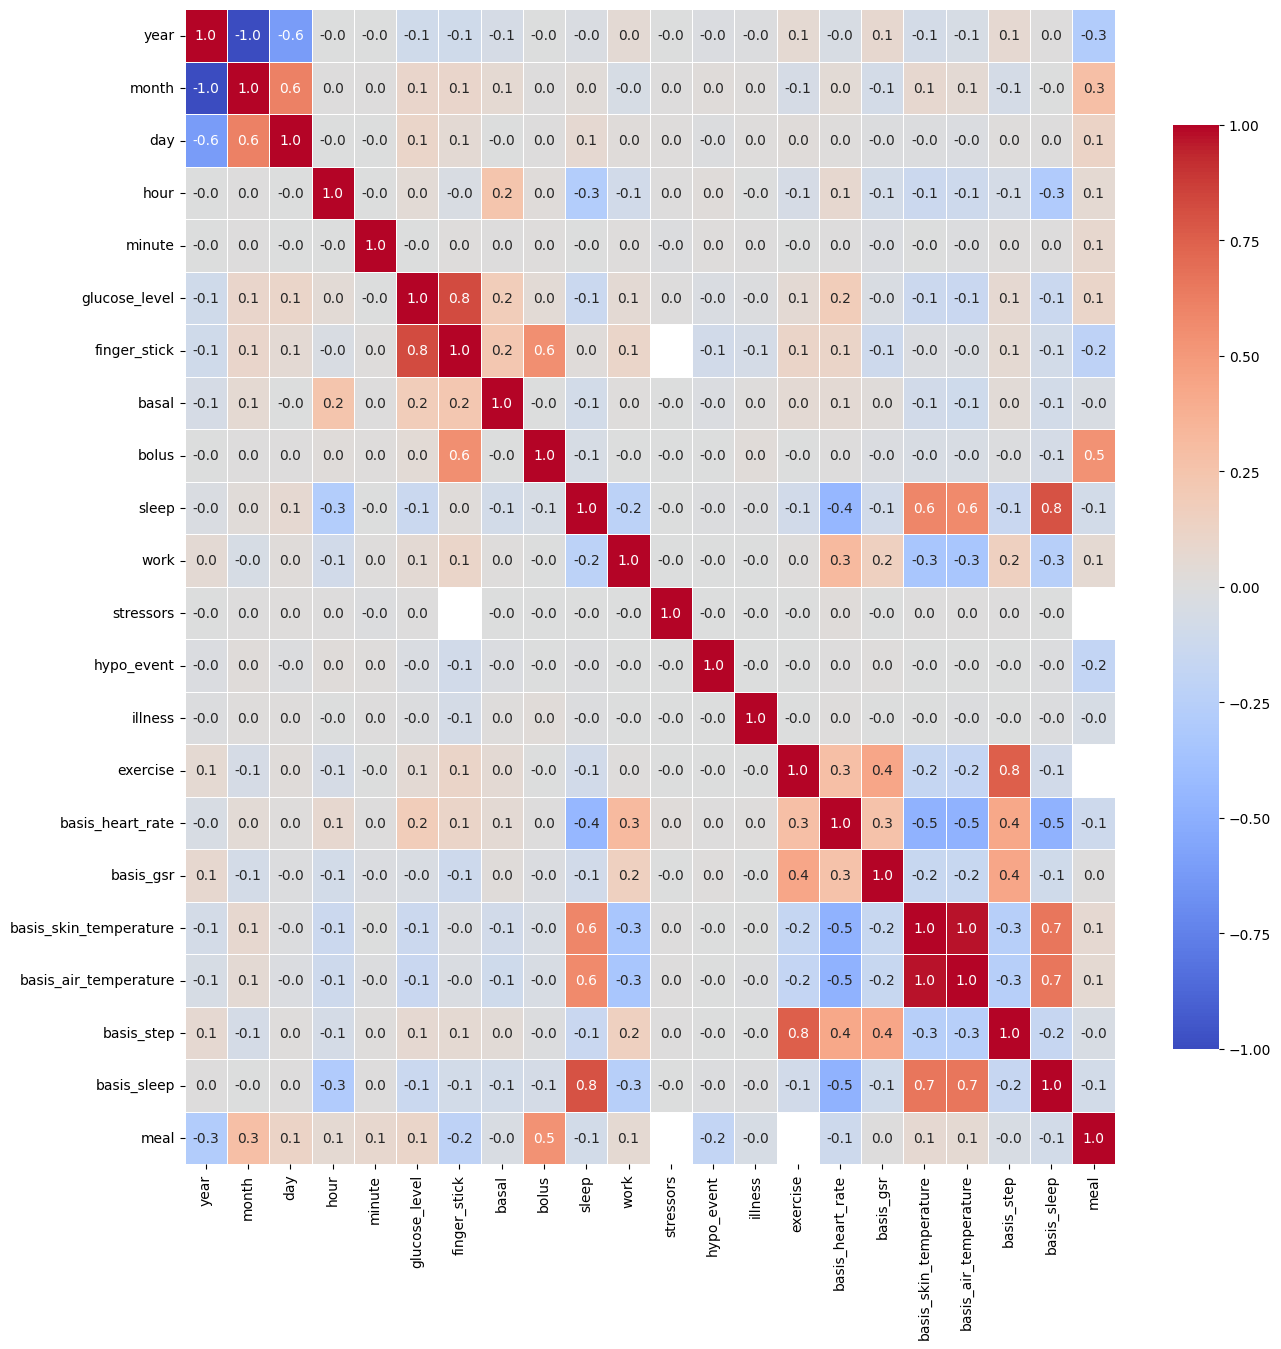

In [18]:
## Numèric vs Numèric: matriu de correlació + scatter de parelles fortes
corr = df_559_train[num_col].corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True, fmt=".1f", cmap="coolwarm", linewidths=.5, cbar_kws={"shrink": .8})
plt.show()